# Stage 7 — Multimodal Dataset Construction

## Goal

Convert the HAM10000 classification dataset into a multimodal
instruction-tuning dataset suitable for adapting a vision-language model.

Each training example will combine:

- a dermatoscopic image
- a text instruction/question
- a target response

This dataset will be used in Stage 8 for parameter-efficient VLM
fine-tuning with NVIDIA NeMo tooling.

The task is educational/research-oriented and is not intended for
clinical diagnosis.

### Load data

In [33]:
from pathlib import Path

import pandas as pd
from PIL import Image

PROJECT_ROOT = Path("..")

METADATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata_splits.csv"
)

df = pd.read_csv(METADATA_PATH)

print(df.shape)
df.head()

(10015, 9)


,lesion_id,image_id,dx,dx_type,age,sex,localization,split,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,val,data/raw/ham10000/HAM10000_images_part_...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,val,data/raw/ham10000/HAM10000_images_part_...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,train,data/raw/ham10000/HAM10000_images_part_...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,train,data/raw/ham10000/HAM10000_images_part_...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,train,data/raw/ham10000/HAM10000_images_part_...


In [34]:
print(
    df["split"]
    .value_counts()
)

print()

print(
    pd.crosstab(
        df["split"],
        df["dx"],
    )
)

split
train    7002
val      1532
test     1481
Name: count, dtype: int64

dx     akiec  bcc  bkl  df  mel    nv  vasc
split                                      
test      46   71  168  20  165   992    19
train    230  366  774  76  778  4679    99
val       51   77  157  19  170  1034    24


In [35]:
#Get human readable class names
CLASS_NAMES = {
    "akiec": (
        "actinic keratosis / "
        "intraepithelial carcinoma"
    ),
    "bcc": "basal cell carcinoma",
    "bkl": "benign keratosis-like lesion",
    "df": "dermatofibroma",
    "mel": "melanoma",
    "nv": "melanocytic nevus",
    "vasc": "vascular lesion",
}

In [36]:
for abbreviation, name in CLASS_NAMES.items():
    print(
        f"{abbreviation:5s} -> {name}"
    )

akiec -> actinic keratosis / intraepithelial carcinoma
bcc   -> basal cell carcinoma
bkl   -> benign keratosis-like lesion
df    -> dermatofibroma
mel   -> melanoma
nv    -> melanocytic nevus
vasc  -> vascular lesion


## Create Instructions
Basic idea is to ask it questions we know the answer to, nad provide those answers as well.

In our case, we'll ask/prompt it to classify images, and then we provide the correct classification.

In [37]:
INSTRUCTION = (
    "Classify the skin lesion in this "
    "dermatoscopic image. "
    "Return the lesion category."
)

In [38]:
#Create multimodal records
records = []

for _, row in df.iterrows():

    record = {
        "image_id": row["image_id"],
        "image_path": row["image_path"],
        "lesion_id": row["lesion_id"],
        "split": row["split"],
        "class_abbreviation": row["dx"],
        "instruction": INSTRUCTION,
        "response": CLASS_NAMES[row["dx"]],
    }

    records.append(record)

multimodal_df = pd.DataFrame(records)

multimodal_df.head()

,image_id,image_path,lesion_id,split,class_abbreviation,instruction,response
0,ISIC_0027419,data/raw/ham10000/HAM10000_images_part_...,HAM_0000118,val,bkl,Classify the skin lesion in this dermatoscopic...,benign keratosis-like lesion
1,ISIC_0025030,data/raw/ham10000/HAM10000_images_part_...,HAM_0000118,val,bkl,Classify the skin lesion in this dermatoscopic...,benign keratosis-like lesion
2,ISIC_0026769,data/raw/ham10000/HAM10000_images_part_...,HAM_0002730,train,bkl,Classify the skin lesion in this dermatoscopic...,benign keratosis-like lesion
3,ISIC_0025661,data/raw/ham10000/HAM10000_images_part_...,HAM_0002730,train,bkl,Classify the skin lesion in this dermatoscopic...,benign keratosis-like lesion
4,ISIC_0031633,data/raw/ham10000/HAM10000_images_part_...,HAM_0001466,train,bkl,Classify the skin lesion in this dermatoscopic...,benign keratosis-like lesion


In [39]:
multimodal_df["response"] = (
    multimodal_df["class_abbreviation"]
)

In [40]:
example = multimodal_df.iloc[0]

for key, value in example.items():
    print(f"{key}: {value}")

image_id: ISIC_0027419
image_path: data/raw/ham10000/HAM10000_images_part_1/ISIC_0027419.jpg
lesion_id: HAM_0000118
split: val
class_abbreviation: bkl
instruction: Classify the skin lesion in this dermatoscopic image. Return the lesion category.
response: bkl


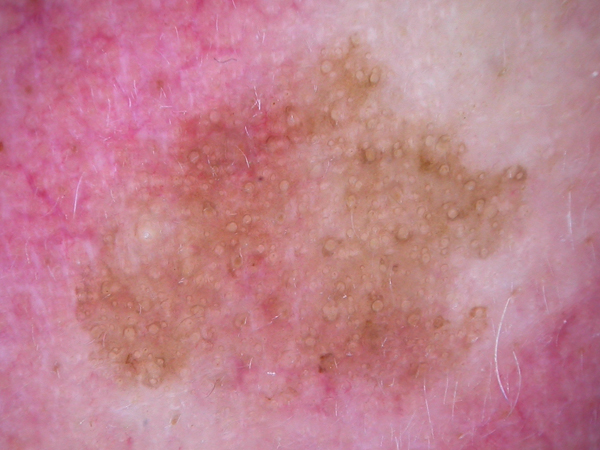

Instruction: Classify the skin lesion in this dermatoscopic image. Return the lesion category.

Target response: mel

Split: train


In [41]:
#Confirm paths all work
example = multimodal_df.sample(
    1,
    random_state=42,
).iloc[0]

image = Image.open(
    PROJECT_ROOT / example["image_path"]
).convert("RGB")

display(image)

print(
    "Instruction:",
    example["instruction"],
)

print(
    "\nTarget response:",
    example["response"],
)

print(
    "\nSplit:",
    example["split"],
)

We could use ONE QUESTION everywhere, or what we will do here is have small set of questions and pick one for each image (only using each image once), that way we can experiment with and learn about linguistic variety as well.

In [42]:
# INSTRUCTIONS = [
#     (
#         "Classify the skin lesion in this "
#         "dermatoscopic image. "
#         "Return the lesion category."
#     ),
#     (
#         "What lesion category is shown in "
#         "this dermatoscopic image?"
#     ),
#     (
#         "Identify the lesion category shown "
#         "in this image."
#     ),
#     (
#         "Which skin lesion category best "
#         "matches this dermatoscopic image?"
#     ),
# ]

In [43]:
CLASSIFICATION_INSTRUCTION = """
Classify the skin lesion in this dermatoscopic image into exactly
one of the following categories:

akiec = actinic keratosis / intraepithelial carcinoma
bcc = basal cell carcinoma
bkl = benign keratosis-like lesion
df = dermatofibroma
mel = melanoma
nv = melanocytic nevus
vasc = vascular lesion

Return only the category abbreviation.
""".strip()

print(CLASSIFICATION_INSTRUCTION)

Classify the skin lesion in this dermatoscopic image into exactly
one of the following categories:

akiec = actinic keratosis / intraepithelial carcinoma
bcc = basal cell carcinoma
bkl = benign keratosis-like lesion
df = dermatofibroma
mel = melanoma
nv = melanocytic nevus
vasc = vascular lesion

Return only the category abbreviation.


In [44]:
#Asign prompts
import random

RANDOM_SEED = 42

rng = random.Random(
    RANDOM_SEED
)

multimodal_df["instruction"] = [
    rng.choice(INSTRUCTIONS)
    for _ in range(len(multimodal_df))
]

#Use same insructions everywhere
multimodal_df["instruction"] = (
    CLASSIFICATION_INSTRUCTION
)

In [45]:
print(
    "Unique instructions:",
    multimodal_df["instruction"].nunique(),
)

print()

print(
    multimodal_df["instruction"].iloc[0]
)

Unique instructions: 1

Classify the skin lesion in this dermatoscopic image into exactly
one of the following categories:

akiec = actinic keratosis / intraepithelial carcinoma
bcc = basal cell carcinoma
bkl = benign keratosis-like lesion
df = dermatofibroma
mel = melanoma
nv = melanocytic nevus
vasc = vascular lesion

Return only the category abbreviation.


In [46]:
multimodal_df[
    [
        "class_abbreviation",
        "response",
    ]
].head(10)

,class_abbreviation,response
0,bkl,bkl
1,bkl,bkl
2,bkl,bkl
3,bkl,bkl
4,bkl,bkl
5,bkl,bkl
6,bkl,bkl
7,bkl,bkl
8,bkl,bkl
9,bkl,bkl


In [47]:
multimodal_df[
    "instruction"
].value_counts()

instruction
Classify the skin lesion in this dermatoscopic image into exactly\none of the following categories:\n\nakiec = actinic keratosis / intraepithelial carcinoma\nbcc = basal cell carcinoma\nbkl = benign keratosis-like lesion\ndf = dermatofibroma\nmel = melanoma\nnv = melanocytic nevus\nvasc = vascular lesion\n\nReturn only the category abbreviation.    10015
Name: count, dtype: int64

In [48]:
print(
    "Rows:",
    len(multimodal_df)
)

print(
    "Unique images:",
    multimodal_df[
        "image_id"
    ].nunique()
)

Rows: 10015
Unique images: 10015


In [49]:
#Check out example
examples = (
    multimodal_df
    .sample(
        3,
        random_state=42,
    )
)

for _, example in examples.iterrows():

    print("=" * 60)

    print(
        "Image:",
        example["image_id"]
    )

    print(
        "Split:",
        example["split"]
    )

    print(
        "\nUSER:"
    )

    print(
        example["instruction"]
    )

    print(
        "\nASSISTANT:"
    )

    print(
        example["response"]
    )

    print()

Image: ISIC_0033272
Split: train

USER:
Classify the skin lesion in this dermatoscopic image into exactly
one of the following categories:

akiec = actinic keratosis / intraepithelial carcinoma
bcc = basal cell carcinoma
bkl = benign keratosis-like lesion
df = dermatofibroma
mel = melanoma
nv = melanocytic nevus
vasc = vascular lesion

Return only the category abbreviation.

ASSISTANT:
mel

Image: ISIC_0031923
Split: val

USER:
Classify the skin lesion in this dermatoscopic image into exactly
one of the following categories:

akiec = actinic keratosis / intraepithelial carcinoma
bcc = basal cell carcinoma
bkl = benign keratosis-like lesion
df = dermatofibroma
mel = melanoma
nv = melanocytic nevus
vasc = vascular lesion

Return only the category abbreviation.

ASSISTANT:
nv

Image: ISIC_0026652
Split: train

USER:
Classify the skin lesion in this dermatoscopic image into exactly
one of the following categories:

akiec = actinic keratosis / intraepithelial carcinoma
bcc = basal cell carc

In [50]:
#Verify no leakage
train_lesions = set(
    multimodal_df.loc[
        multimodal_df["split"] == "train",
        "lesion_id",
    ]
)

val_lesions = set(
    multimodal_df.loc[
        multimodal_df["split"] == "val",
        "lesion_id",
    ]
)

test_lesions = set(
    multimodal_df.loc[
        multimodal_df["split"] == "test",
        "lesion_id",
    ]
)

print(
    "Train/val overlap:",
    len(train_lesions & val_lesions)
)

print(
    "Train/test overlap:",
    len(train_lesions & test_lesions)
)

print(
    "Val/test overlap:",
    len(val_lesions & test_lesions)
)

Train/val overlap: 0
Train/test overlap: 0
Val/test overlap: 0


## Adapt VLM

We will now start training the VLM to help it learn to adapt to our problem.

**Note 1: Use of PEFT/LoRA**

We will make use of PEFT/LoRA.  PEFT is Parameter Efficient Fine Tuning, whihc is the general idea of only making some of the parameters trainable.  We've already done that in earlier stages when we made only the last classifier layer trainable, or even only made the last conv layer of ResNet trainable.

LoRA, Low Rank Adaption, is a specific type of PEFT.  Instead of making an entire matrix W of size NxN all trainable, we find two smaller matrices A (nXN) and B (Nxn) that can mutliply together to give size NxN for how to update W, but with much fewer parameters, so much more efficient training on our small GPU.

PEFT/LoRA will become important when we bring in NeMo.

**Note 2: Validation**

We will have to be careful when running validation metrics that we dont' give the model the answer, need to only give it the prompt.

In [51]:
#Save off the multimodal dataset
OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "multimodal_dataset.csv"
)

multimodal_df.to_csv(
    OUTPUT_PATH,
    index=False,
)

print(
    f"Saved {len(multimodal_df)} records "
    f"to {OUTPUT_PATH}"
)

Saved 10015 records to ../data/processed/multimodal_dataset.csv


In [52]:
#Verify
check_df = pd.read_csv(
    OUTPUT_PATH
)

print(check_df.shape)

print(
    check_df["split"]
    .value_counts()
)

check_df.head()

(10015, 7)
split
train    7002
val      1532
test     1481
Name: count, dtype: int64


,image_id,image_path,lesion_id,split,class_abbreviation,instruction,response
0,ISIC_0027419,data/raw/ham10000/HAM10000_images_part_...,HAM_0000118,val,bkl,Classify the skin lesion in this dermatoscopic...,bkl
1,ISIC_0025030,data/raw/ham10000/HAM10000_images_part_...,HAM_0000118,val,bkl,Classify the skin lesion in this dermatoscopic...,bkl
2,ISIC_0026769,data/raw/ham10000/HAM10000_images_part_...,HAM_0002730,train,bkl,Classify the skin lesion in this dermatoscopic...,bkl
3,ISIC_0025661,data/raw/ham10000/HAM10000_images_part_...,HAM_0002730,train,bkl,Classify the skin lesion in this dermatoscopic...,bkl
4,ISIC_0031633,data/raw/ham10000/HAM10000_images_part_...,HAM_0001466,train,bkl,Classify the skin lesion in this dermatoscopic...,bkl


In [53]:
#Verify splits
train_mm_df = (
    multimodal_df[
        multimodal_df["split"] == "train"
    ]
    .reset_index(drop=True)
)

val_mm_df = (
    multimodal_df[
        multimodal_df["split"] == "val"
    ]
    .reset_index(drop=True)
)

test_mm_df = (
    multimodal_df[
        multimodal_df["split"] == "test"
    ]
    .reset_index(drop=True)
)

print("Train:", len(train_mm_df))
print("Val:  ", len(val_mm_df))
print("Test: ", len(test_mm_df))

Train: 7002
Val:   1532
Test:  1481


In [54]:
#Save splits
SPLIT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "multimodal"
)

SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for split_name, split_df in [
    ("train", train_mm_df),
    ("val", val_mm_df),
    ("test", test_mm_df),
]:

    output_path = (
        SPLIT_DIR
        / f"{split_name}.csv"
    )

    split_df.to_csv(
        output_path,
        index=False,
    )

    print(
        f"{split_name:5s}: "
        f"{len(split_df):5d} records -> "
        f"{output_path}"
    )

train:  7002 records -> ../data/processed/multimodal/train.csv
val  :  1532 records -> ../data/processed/multimodal/val.csv
test :  1481 records -> ../data/processed/multimodal/test.csv
